In [7]:
"""
2D Point Demo - simple demo to test if the CNF can learn a 2D distribution of points. No dynamics.
"""

using ComponentArrays, DiffEqFlux, OrdinaryDiffEq, Optimization, Random,
      OptimizationOptimisers, OptimizationOptimJL, Plots, CUDA, Statistics

=== Step 1: Generating 2D point data ===


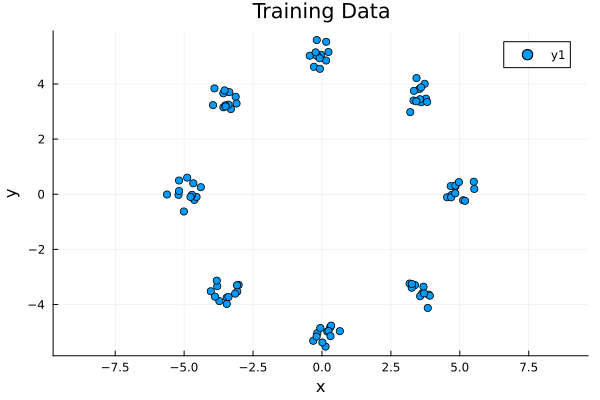

In [2]:
# ── 1.  Generate 2D point data ────────────────────────────────────────────────────────
println("=== Step 1: Generating 2D point data ===")
# generate N_train samples from a 2D circle of gaussians
N_train = 100
N_gaussians = 8
radius = 5.0
gaussian_std = 0.3
angles = range(0, 2π, length=N_gaussians + 1)[1:end-1]
gaussian_centers = [radius * [cos(θ), sin(θ)] for θ in angles]

train_data_cpu = hcat([randn(2, N_train ÷ N_gaussians) .* gaussian_std .+ center for center in gaussian_centers]...)
# plot the training data
scatter(train_data_cpu[1, :], train_data_cpu[2, :], title="Training Data", xlabel="x", ylabel="y", aspect_ratio=1)

In [3]:
train_data = CUDA.cu(Float32.(train_data_cpu))

2×96 CuArray{Float32, 2, CUDACore.DeviceMemory}:
  4.54016  4.83847   5.52611   5.50836   …   3.91255   3.70394   3.26072
 -0.11088  0.281092  0.192762  0.454055     -3.6805   -3.59954  -3.25453

In [4]:
# ── 2.  Set up CNF model ────────────────────────────────────────────────────────
sysdim = 2
hidden_size = 8
nn = Chain(Dense(sysdim, hidden_size, tanh), Dense(hidden_size, sysdim, tanh))
tspan = (0.0f0, 1.0f0)

ffjord_mdl = FFJORD(nn, tspan, (2,), Tsit5(); ad = AutoZygote(), sensealg = InterpolatingAdjoint())
ps, st = Lux.setup(Xoshiro(0), ffjord_mdl)
ps = ComponentArray(ps)
ps = CUDA.cu(ComponentArray(ps))
st = CUDA.cu(st)

model = StatefulLuxLayer{true}(ffjord_mdl, nothing, st)

StatefulLuxLayer{Val{true}()}(
    FFJORD(
        model = Chain(
            layer_1 = Dense(2 => 8, tanh),        # 24 parameters
            layer_2 = Dense(8 => 2, tanh),        # 18 parameters
        ),
    ),
)         # Total: 42 parameters,
          #        plus 0 states.

In [ ]:
# ── 3.  Train the CNF ────────────────────────────────────────────────────────
function loss(θ)
    logpx, λ₁, λ₂ = model(train_data, θ)
    return -mean(logpx)
end

function cb(state, l)
    @info "FFJORD Training" loss=l
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((x, p) -> loss(x), adtype)
optprob = Optimization.OptimizationProblem(optf, ps)

OptimizationProblem. In-place: true
u0: ComponentVector{Float32, CuArray{Float32, 1, CUDACore.DeviceMemory}, Tuple{Axis{(layer_1 = ViewAxis(1:24, Axis(weight = ViewAxis(1:16, ShapedAxis((8, 2))), bias = ViewAxis(17:24, Shaped1DAxis((8,))))), layer_2 = ViewAxis(25:42, Axis(weight = ViewAxis(1:16, ShapedAxis((2, 8))), bias = ViewAxis(17:18, Shaped1DAxis((2,))))))}}}(layer_1 = (weight = Float32[-1.8019577 -0.36156967; -0.18273845 -1.9202054; … ; -1.581186 -0.8435899; 1.7986798 1.9459964], bias = Float32[-0.39985895, -0.58414537, -0.09390596, -0.21002297, -0.0017298752, -0.4337521, 0.014917371, -0.54165936]), layer_2 = (weight = Float32[0.48554128 -0.17971271 … 0.25504714 0.58191276; 0.31769067 0.56065893 … -0.2160369 0.107648455], bias = Float32[0.19680391, 0.2629641]))

In [ ]:
res1 = Optimization.solve(
    optprob, OptimizationOptimisers.Adam(0.01f0); maxiters = 100, callback = cb)

┌ Info: FFJORD Training
│   loss = 15.758395
└ @ Main /home/rsmukk/data/18337/juliaproj/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X12sdnNjb2RlLXJlbW90ZQ==.jl:8


In [ ]:
# Evaluation
using Distances

st_ = (; st..., monte_carlo = false)

actual_pdf = pdf.(data_dist, train_data)
learned_pdf = exp.(ffjord_mdl(train_data, res2.u, st_)[1][1])
train_dis = totalvariation(learned_pdf, actual_pdf) / size(train_data, 2)

# Data Generation
ffjord_dist = FFJORDDistribution(ffjord_mdl, ps, st)
new_data = rand(ffjord_dist, 100)